# Day 4｜AI 廣告精準投放與全通路行銷成效優化

## 從漏斗績效到可控的投放實驗

> **資料使用邊界：** 本 Notebook 使用固定亂數種子產生的教學虛擬資料，不是任何企業的真實營運資料。結果只能用於練習分析流程，不可宣稱為企業事實或因果效果。

### 故事情境

第四天早上，主管把下個月預算放到桌上：四家企業都累積了跨通路虛擬接觸資料，但每個團隊都說自己的渠道最好。你要在下午前回答：預算應維持、加碼或轉移到哪裡？模型要抓更多可能轉換者，還是少打擾不會轉換的人？哪些結論仍需要實驗？

### 今日決策問題

**如何同時用漏斗 KPI、轉換機率與錯誤成本決定預算配置及下一個實驗？**

### 學習目標

- 能正確計算 CTR、CVR、CPA、ROAS 與貢獻毛利
- 能建立 logistic regression 轉換模型
- 能用混淆矩陣、precision、recall、ROC-AUC 評估
- 能依錯誤成本調整分類門檻
- 能提出有規模與風險邊界的全通路預算方案

### Colab 操作提醒

1. 在 Google Drive 建立個人副本。
2. 將對應 CSV 上傳到 Colab `/content`，或保持教材包原始相對路徑。
3. 由上到下依序執行；若 Runtime 重啟，請重新執行全部儲存格。
4. 每個程式碼儲存格後都有繁體中文說明、預期輸出與完成檢核。

### [D4-S01] 載入全通路資料並建立決策邊界

In [1]:
# 本格目的：載入套件並找到教學資料檔
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

# 優先從公開 GitHub Raw 讀取資料；失敗時再使用 /content 或本機相對路徑
import os

RAW_DATA_URL = "https://raw.githubusercontent.com/johnnychao/mcut-m4-business-analytics-2026-student/main/docs/resources/data/day-4-omnichannel-ads.csv"
DATA_FILENAME = "day-4-omnichannel-ads.csv"
LOCAL_FALLBACK_NAMES = [DATA_FILENAME, "day4_omnichannel_ads.csv"]
FORCE_LOCAL_DATA = os.environ.get("M4_FORCE_LOCAL_DATA") == "1"

try:
    # 正式教材 QA 會刻意關閉遠端來源，確認 ../04_data 備援路徑可獨立運作
    if FORCE_LOCAL_DATA:
        raise ConnectionError("M4 Notebook QA：改用本機資料備援")
    df = pd.read_csv(RAW_DATA_URL)
    data_source = RAW_DATA_URL
except Exception as remote_error:
    candidate_paths = []
    for filename in LOCAL_FALLBACK_NAMES:
        candidate_paths.extend([
            Path("/content") / filename,
            Path(filename),
            Path("../04_data") / filename,
            Path("../04_虛擬資料") / filename,
        ])
    data_path = next((path for path in candidate_paths if path.exists()), None)
    if data_path is None:
        raise FileNotFoundError(
            f"GitHub Raw 暫時無法讀取，而且 /content 也找不到 {DATA_FILENAME}。"
        ) from remote_error
    df = pd.read_csv(data_path)
    data_source = str(data_path)

# 所有課堂匯出檔集中放在 outputs，避免散落在 Notebook 旁
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"資料來源：{data_source}")
print(f"資料尺寸：{df.shape}")
display(df.head(3))

資料來源：..\04_data\day-4-omnichannel-ads.csv
資料尺寸：(6000, 14)


,date,company,channel,audience_segment,creative_type,device,impression,clicked,visited,converted,spend,revenue,unit_margin_rate,is_synthetic
0,2025-10-01,雜草町,Meta,新客探索,短影音,mobile,1,0,0,0,4.630,0.000,0.620,True
1,2025-10-02,雜草町,Google,新客探索,短影音,mobile,1,0,0,0,8.330,0.000,0.620,True
2,2025-10-03,雜草町,LINE,新客探索,短影音,mobile,1,0,0,0,3.590,0.000,0.620,True


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 載入 6,000 筆虛擬全通路接觸資料。
- **預期輸出：** 資料尺寸與前三列。
- **完成檢核：** 資料包含四家公司與 is_synthetic。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S02] 選定企業並檢查漏斗邏輯

In [2]:
# 本格目的：選定企業並確認曝光、點擊、造訪、轉換的順序
assert df["is_synthetic"].astype(str).str.lower().eq("true").all()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# TODO：請改成你組負責的企業名稱
SELECTED_COMPANY = "雜草町"
company_df = df.loc[df["company"] == SELECTED_COMPANY].copy()
assert company_df["company"].nunique() == 1 and not company_df.empty

logic_errors = ((company_df["converted"] > company_df["visited"]) | (company_df["visited"] > company_df["clicked"])).sum()
print(f"企業資料筆數：{len(company_df)}")
print(f"漏斗邏輯錯誤筆數：{logic_errors}")
display(company_df[["channel", "audience_segment", "clicked", "visited", "converted", "spend", "revenue"]].head())

企業資料筆數：1500
漏斗邏輯錯誤筆數：0


,channel,audience_segment,clicked,visited,converted,spend,revenue
0,Meta,新客探索,0,0,0,4.630,0.000
1,Google,新客探索,0,0,0,8.330,0.000
2,LINE,新客探索,0,0,0,3.590,0.000
3,Email,新客探索,0,0,0,1.150,0.000
4,YouTube,新客探索,1,0,0,4.610,0.000


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 篩選一家企業，並確認轉換不會在沒有造訪、造訪不會在沒有點擊時出現。
- **預期輸出：** 1,500 筆企業資料與邏輯錯誤數。
- **完成檢核：** logic_errors 應為 0。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S03] 計算 CTR、CVR、CPA、ROAS 與貢獻毛利

In [3]:
# 本格目的：使用正確分母計算 CTR、CVR、CPA、ROAS 與貢獻毛利
channel_kpi = company_df.groupby("channel", as_index=False).agg(
    impressions=("impression", "sum"), clicks=("clicked", "sum"),
    visits=("visited", "sum"), conversions=("converted", "sum"),
    spend=("spend", "sum"), revenue=("revenue", "sum"),
)
channel_kpi["CTR"] = channel_kpi["clicks"] / channel_kpi["impressions"]
channel_kpi["visit_rate"] = channel_kpi["visits"] / channel_kpi["clicks"].replace(0, np.nan)
channel_kpi["CVR"] = channel_kpi["conversions"] / channel_kpi["visits"].replace(0, np.nan)
channel_kpi["CPA"] = channel_kpi["spend"] / channel_kpi["conversions"].replace(0, np.nan)
channel_kpi["ROAS"] = channel_kpi["revenue"] / channel_kpi["spend"].replace(0, np.nan)
channel_kpi["contribution_after_ads"] = channel_kpi["revenue"] * company_df["unit_margin_rate"].median() - channel_kpi["spend"]
display(channel_kpi.round(3).sort_values("contribution_after_ads", ascending=False))

,channel,impressions,clicks,visits,conversions,spend,revenue,CTR,visit_rate,CVR,CPA,ROAS,contribution_after_ads
2,LINE,300,41,27,2,"1,080.100","2,658.680",0.137,0.659,0.074,540.050,2.462,568.282
0,Email,300,38,22,1,358.290,"1,416.420",0.127,0.579,0.045,358.290,3.953,519.890
1,Google,300,51,42,3,"2,177.750","3,917.730",0.170,0.824,0.071,725.917,1.799,251.243
3,Meta,300,21,13,1,"1,465.400","1,603.250",0.070,0.619,0.077,"1,465.400",1.094,-471.385
4,YouTube,300,24,16,0,"1,658.600",0.000,0.080,0.667,0.000,NaN,0.000,"-1,658.600"


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 先加總漏斗事件，再用明確分母計算 KPI；ROAS 之外另估貢獻毛利。
- **預期輸出：** 五個通路 KPI 表。
- **完成檢核：** CTR=點擊/曝光、CVR=購買/造訪，ROAS 不是完整利潤。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S04] 視覺化漏斗規模與通路績效

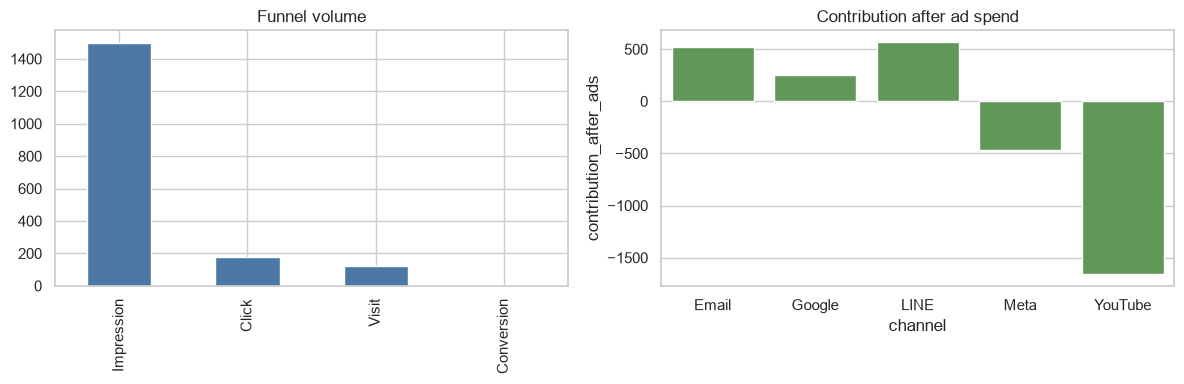

In [4]:
# 本格目的：將規模與效率分開呈現，避免只看單一百分比
funnel = pd.Series({
    "Impression": company_df["impression"].sum(),
    "Click": company_df["clicked"].sum(),
    "Visit": company_df["visited"].sum(),
    "Conversion": company_df["converted"].sum(),
})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
funnel.plot(kind="bar", ax=axes[0], color="#4C78A8", title="Funnel volume")
sns.barplot(data=channel_kpi, x="channel", y="contribution_after_ads", ax=axes[1], color="#59A14F")
axes[1].set_title("Contribution after ad spend")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 左圖顯示漏斗規模，右圖顯示扣除廣告費後的簡化貢獻。
- **預期輸出：** 兩張並列長條圖。
- **完成檢核：** 不能因 CTR 高就跳過後段轉換與成本。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S05] 建立轉換機率 Logistic Regression baseline

In [5]:
# 本格目的：使用可解釋 logistic regression 預測轉換機率
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

feature_cols = ["channel", "audience_segment", "creative_type", "device", "spend", "clicked", "visited"]
categorical_features = ["channel", "audience_segment", "creative_type", "device"]
numeric_features = ["spend", "clicked", "visited"]
X = company_df[feature_cols]
y = company_df["converted"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=20260716,
)
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])
conversion_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=20260716)),
])
conversion_model.fit(X_train, y_train)
conversion_probability = conversion_model.predict_proba(X_test)[:, 1]
print("測試集轉換率：", round(float(y_test.mean()), 4))

測試集轉換率： 0.0053


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以分層切分保留轉換比例，Pipeline 完成類別編碼與 logistic regression。
- **預期輸出：** 測試集轉換率。
- **完成檢核：** 切分使用 stratify；模型預測的是機率，不是證明廣告造成轉換。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S06] 評估 0.5 門檻與混淆矩陣

,threshold,precision,recall,ROC_AUC
0,0.500,0.056,0.500,0.958


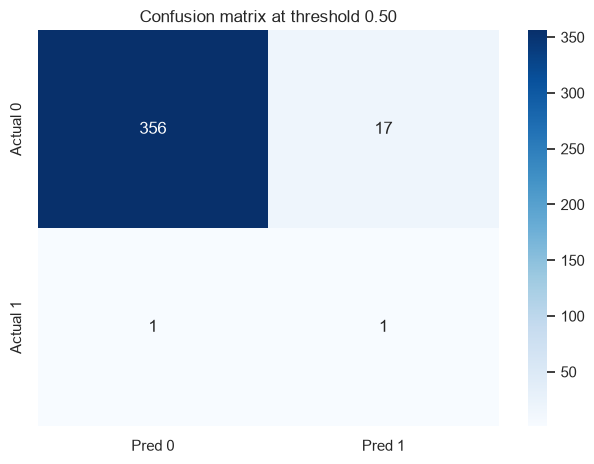

In [6]:
# 本格目的：同時查看混淆矩陣、precision、recall 與 ROC-AUC
pred_05 = (conversion_probability >= 0.50).astype(int)
metrics_05 = pd.DataFrame([{
    "threshold": 0.50,
    "precision": precision_score(y_test, pred_05, zero_division=0),
    "recall": recall_score(y_test, pred_05, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, conversion_probability),
}])
display(metrics_05.round(3))

cm = confusion_matrix(y_test, pred_05)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion matrix at threshold 0.50")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** accuracy 容易被多數未轉換者影響，因此改看 precision、recall、AUC 與錯誤型態。
- **預期輸出：** 評估表與 2×2 混淆矩陣。
- **完成檢核：** 能指出 false positive 是投放浪費，false negative 是漏掉可能轉換者。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S07] 比較三個分類門檻的取捨

,threshold,precision,recall,false_positive,false_negative
0,0.250,0.042,0.500,23,1
1,0.500,0.056,0.500,17,1
2,0.700,0.077,0.500,12,1


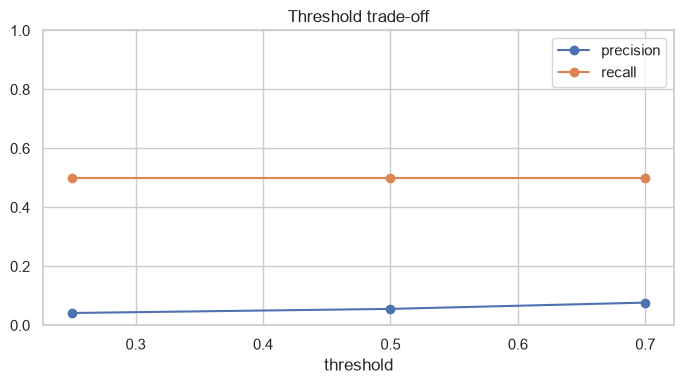

In [7]:
# 本格目的：把精準度與召回率的取捨轉成商業選擇
threshold_rows = []
for threshold in [0.25, 0.50, 0.70]:
    pred = (conversion_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    threshold_rows.append({
        "threshold": threshold, "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "false_positive": fp, "false_negative": fn,
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))
threshold_table.plot(x="threshold", y=["precision", "recall"], marker="o", ylim=(0, 1), figsize=(7, 4))
plt.title("Threshold trade-off")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 比較 0.25、0.50、0.70，觀察抓到更多轉換者與減少浪費之間的取捨。
- **預期輸出：** 門檻表與 precision／recall 折線。
- **完成檢核：** 門檻選擇需說明媒體成本、打擾風險與團隊承接能力。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S08] 以錯誤成本選擇暫定門檻

In [8]:
# 本格目的：將 false positive 與 false negative 轉成可比較的簡化成本
# TODO：依企業情境調整兩種錯誤成本
FALSE_POSITIVE_COST = 80
FALSE_NEGATIVE_COST = 450
threshold_table["estimated_error_cost"] = (
    threshold_table["false_positive"] * FALSE_POSITIVE_COST
    + threshold_table["false_negative"] * FALSE_NEGATIVE_COST
)
best_threshold = threshold_table.sort_values("estimated_error_cost").iloc[0]
display(threshold_table.round(2))
print(f"簡化成本最低門檻：{best_threshold['threshold']:.2f}")
print("提醒：成本是假設，必須在企業資料與倫理治理下重新確認。")

,threshold,precision,recall,false_positive,false_negative,estimated_error_cost
0,0.250,0.040,0.500,23,1,2290
1,0.500,0.060,0.500,17,1,1810
2,0.700,0.080,0.500,12,1,1410


簡化成本最低門檻：0.70
提醒：成本是假設，必須在企業資料與倫理治理下重新確認。


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 用兩個透明假設把投放浪費與漏失機會換成簡化成本，協助挑門檻。
- **預期輸出：** 含估計錯誤成本的門檻表。
- **完成檢核：** 學生能說明若兩種成本改變，最佳門檻也可能改變。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S09] 建立一百萬元核心與探索預算情境

In [9]:
# 本格目的：根據貢獻效率配置主要預算，同時保留探索額度
TOTAL_BUDGET = 1_000_000
EXPLORATION_SHARE = 0.20
channel_plan = channel_kpi.copy()
channel_plan["efficiency_score"] = (channel_plan["contribution_after_ads"] / channel_plan["spend"]).clip(lower=0.05)
channel_plan["core_weight"] = channel_plan["efficiency_score"] / channel_plan["efficiency_score"].sum()
channel_plan["core_budget"] = TOTAL_BUDGET * (1 - EXPLORATION_SHARE) * channel_plan["core_weight"]
channel_plan["exploration_budget"] = TOTAL_BUDGET * EXPLORATION_SHARE / len(channel_plan)
channel_plan["recommended_budget"] = (channel_plan["core_budget"] + channel_plan["exploration_budget"]).round(-3)

# 四捨五入後把差額補到最高效率通路，確保總額等於 100 萬
budget_gap = TOTAL_BUDGET - channel_plan["recommended_budget"].sum()
top_index = channel_plan["efficiency_score"].idxmax()
channel_plan.loc[top_index, "recommended_budget"] += budget_gap
display(channel_plan[["channel", "CTR", "CVR", "ROAS", "contribution_after_ads", "recommended_budget"]].round(3))
print("預算合計：", int(channel_plan["recommended_budget"].sum()))

,channel,CTR,CVR,ROAS,contribution_after_ads,recommended_budget
0,Email,0.127,0.045,3.953,519.890,"570,000.000"
1,Google,0.170,0.071,1.799,251.243,"82,000.000"
2,LINE,0.137,0.074,2.462,568.282,"232,000.000"
3,Meta,0.070,0.077,1.094,-471.385,"58,000.000"
4,YouTube,0.080,0.000,0.000,"-1,658.600","58,000.000"


預算合計： 1000000


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 80% 依簡化貢獻效率配置，20% 平均保留探索，並修正四捨五入差額。
- **預期輸出：** 五通路預算表，合計 1,000,000。
- **完成檢核：** 預算不是自動投放指令；需檢查樣本量、容量與治理。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S10] 形成全通路投放實驗卡與交付

In [10]:
# 本格目的：把預算建議轉成下一輪可檢驗實驗
top_channel = channel_plan.sort_values("recommended_budget", ascending=False).iloc[0]
test_card = pd.DataFrame({
    "item": ["企業", "優先測試通路", "建議門檻", "核心 KPI", "停止條件", "因果限制"],
    "content": [
        SELECTED_COMPANY,
        top_channel["channel"],
        f"{best_threshold['threshold']:.2f}",
        "貢獻毛利、CPA、轉換數；CTR 只作前段診斷",
        "連續兩個觀察期貢獻毛利低於 0，或 CPA 高於事前上限",
        "預測誰較可能轉換，不等於廣告造成轉換；需要 A/B test 驗證增量",
    ],
})
display(test_card)
channel_plan.to_csv(OUTPUT_DIR / "Day4_全通路預算方案.csv", index=False, encoding="utf-8-sig")
test_card.to_csv(OUTPUT_DIR / "Day4_投放實驗卡.csv", index=False, encoding="utf-8-sig")

,item,content
0,企業,雜草町
1,優先測試通路,Email
2,建議門檻,0.70
3,核心 KPI,貢獻毛利、CPA、轉換數；CTR 只作前段診斷
4,停止條件,連續兩個觀察期貢獻毛利低於 0，或 CPA 高於事前上限
5,因果限制,預測誰較可能轉換，不等於廣告造成轉換；需要 A/B test 驗證增量


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 把通路、門檻、KPI、停止條件與因果限制寫成實驗卡。
- **預期輸出：** 六列實驗卡與兩個輸出 CSV。
- **完成檢核：** 至少有一項停止條件，且明確區分預測與廣告增量效果。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

## 當日學習驗收

> 請先獨立作答；本 Notebook 不顯示答案。答案與解析收錄於教師版題庫。

### 第 1 題

CTR 的計算為何？

- A. 點擊÷曝光
- B. 購買÷點擊
- C. 營收÷花費
- D. 花費÷購買

### 第 2 題

CVR 在本課定義為何？

- A. 購買÷造訪
- B. 曝光÷購買
- C. 成本÷營收
- D. 點擊÷花費

### 第 3 題

ROAS 為何？

- A. 廣告營收÷廣告花費
- B. 花費÷點擊
- C. 購買÷曝光
- D. 毛利÷庫存

### 第 4 題

類別不平衡時，不能只看哪個指標？

- A. accuracy
- B. precision
- C. recall
- D. ROC-AUC

### 第 5 題

調低分類門檻通常會如何影響 recall？

- A. 通常提高
- B. 一定降為零
- C. 完全不變
- D. 無法計算

### 第 6 題

混淆矩陣的 false positive 在行銷上可能代表？

- A. 投放給不會轉換的人
- B. 成功轉換
- C. 完全沒有曝光
- D. 收入一定上升

### 第 7 題

若 ROAS 高但毛利很低，合理做法是？

- A. 仍應無條件加碼
- B. 加入成本與毛利後再判斷
- C. 刪除所有轉換
- D. 只改圖表顏色

### 第 8 題

模型分數可直接證明廣告造成購買嗎？

- A. 可以
- B. 不可以
- C. AUC>0.7 就可以
- D. 樣本多就一定可以

### 第 9 題

預算重新配置前，至少應檢查？

- A. 樣本量、成本、轉換與可擴張性
- B. 只看最高 CTR
- C. 只看單一日期
- D. 只看模型係數正負

### 第 10 題

全通路 KPI 最終要連到什麼？

- A. 下一個決策與實驗
- B. 更多裝飾圖
- C. 固定的業界答案
- D. 只有曝光量

## 實作題

選擇一家公司，完成通路漏斗 KPI、logistic 轉換模型與三個門檻比較，提出總預算 100 萬元的配置方案。建議須包含一項加碼、一項維持／縮減、一項探索實驗及停止條件。

### 評分規準

- 漏斗 KPI（20 分）：分母、成本與營收指標正確
- 分類模型（20 分）：切分、前處理與 baseline 可重跑
- 錯誤成本（20 分）：混淆矩陣與門檻選擇有商業理由
- 預算方案（25 分）：金額合計正確且有規模風險
- 實驗與限制（15 分）：清楚區分預測與增量因果

### 繳交前檢查

- 由上到下 Restart and Run All 無錯誤。
- 所有圖表、指標與結論均顯示所選企業。
- 結論明示虛擬資料、限制與下一步驗證。
- 未將預測、相關或分群寫成因果證明。